# Upper vs. Lower Quartile Decile Composite: Pre-ET, High-Shear Rapid IKE Change

For pre-ET (<48hr from extratropical transition), high-shear (>10 m/s) timesteps,
splits storms into the upper and lower quartile of 6-hour IKE change, then compares
the two groups across nine lagged (24hr prior) predictors -- Vmax, Pmin, mean R34, a
wavenumber-1 R34 asymmetry index, latitude, translation speed/direction, total IKE,
shear magnitude, and the prior 24hr Vmax change.


## Paths

Set once per machine. See the repo README ("Setting IBTRACS_PATH / IKE_OUTPUT_DIR")
for why these are set here rather than relying on a shell-level `export`.

In [1]:
import os
os.environ["IBTRACS_PATH"] = "/home/sydney.e.walters/IBTrACS"
os.environ["SHIPS_PATH"] = "/data/jacob.carstens/SHIPS"
os.environ["IKE_OUTPUT_DIR"] = "/home/sydney.e.walters/IBTrACS_Manuscript_Figures"


## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

from ike_climatology import config
from ike_climatology.decile_composite import (
    load_master_dataframe_decile,
    compute_decile_composite,
    compare_basins_within_group,
    levene_upper_vs_lower,
)


## Data extraction

Only North Atlantic and West Pacific, matching the source script.

In [3]:
BASINS = ["North Atlantic", "West Pacific"]

master_df = load_master_dataframe_decile(
    basins=BASINS,
    ibtracs_file_map=config.IBTRACS_FILE_MAP,
    ships_file_map=config.SHIPS_FILE_MAP,
    basin_codes=config.IBTRACS_BASIN_CODES,
    ships_base_path=config.SHIPS_BASE_PATH,
    start_year=config.START_YEAR,
    end_year=config.END_YEAR,
    land_interaction_threshold_km=config.LAND_INTERACTION_THRESHOLD_KM,
)

if master_df.empty:
    raise RuntimeError("No processable storm data found -- check IBTRACS_PATH/SHIPS_PATH.")


--- Loading Data (2004-2024) ---

--- Loading Data for North Atlantic ---
Processing 380 storms in North Atlantic...
        - Filtered out 2 crossover storms.

--- Loading Data for West Pacific ---
Processing 622 storms in West Pacific...
        - Filtered out 16 crossover storms.

--- Master DataFrame: 14,171 tropical-phase observations ---


## Plotting function

Multi-panel boxplot (+ jittered strip plot) comparing upper- vs. lower-quartile
distributions for each predictor, with a Mann-Whitney significance marker per panel.

In [4]:
def plot_decile_boxplots(composite, predictors, basin, output_dir, lag_hours):
    n_predictors = len(predictors)
    ncols = 5
    nrows = int(np.ceil(n_predictors / ncols))

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4 * nrows))
    axes = axes.flatten() if nrows > 1 else ([axes] if n_predictors == 1 else axes)

    palette = {"Upper Quartile": "firebrick", "Lower Quartile": "peachpuff"}
    group_order = ["Upper Quartile", "Lower Quartile"]

    for i, (col, (label, unit)) in enumerate(predictors.items()):
        ax = axes[i]
        plot_data = composite[["group", col]].dropna()
        if plot_data.empty:
            ax.text(0.5, 0.5, "Insufficient data", ha="center", va="center",
                    transform=ax.transAxes, fontsize=12)
            ax.set_title(label, fontsize=12, weight="bold")
            continue

        sns.boxplot(
            x="group", y=col, data=plot_data, ax=ax,
            order=group_order, palette=palette, hue="group", legend=False,
            showfliers=False, width=0.5,
        )
        sns.stripplot(
            x="group", y=col, data=plot_data, ax=ax,
            order=group_order, color="black", alpha=0.35, size=3, jitter=0.15,
        )

        u_vals = plot_data[plot_data["group"] == group_order[0]][col].dropna()
        l_vals = plot_data[plot_data["group"] == group_order[1]][col].dropna()
        if len(u_vals) >= 5 and len(l_vals) >= 5:
            try:
                _, pval = mannwhitneyu(u_vals, l_vals, alternative="two-sided")
                sig = "***" if pval < 0.001 else ("**" if pval < 0.01 else ("*" if pval < 0.05 else "n.s."))
                title = f"{label}\np = {pval:.3f} ({sig})"
            except ValueError:
                title = label
        else:
            title = label

        ax.set_title(title, fontsize=11, weight="bold")
        ax.set_xlabel("")
        ax.set_ylabel(unit, fontsize=10)
        ax.tick_params(axis="x", labelsize=9)
        ax.tick_params(axis="y", labelsize=9)
        ax.grid(True, axis="y", linestyle="--", alpha=0.5)

    for j in range(n_predictors, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(
        f"{basin} Pre-ET High-Shear: Upper vs Lower Quartile Composites "
        f"(predictors at $t = -{lag_hours}$ hr)",
        fontsize=15, weight="bold",
    )
    fig.tight_layout()
    fig.subplots_adjust(top=0.90, hspace=0.40)

    fname = f'{basin.replace(" ", "")}_quartile_composite_boxplots.png'
    plt.savefig(os.path.join(output_dir, fname), dpi=300, bbox_inches="tight")
    plt.show()
    print(f"  Plot saved: {fname}")


## Run the composite analysis, per basin

For each basin: compute the composite, print the summary table and the storms
contributing to each quartile, save the summary and underlying-observations CSVs,
then plot.


  UPPER vs LOWER DECILE COMPOSITE — North Atlantic
  Upper decile threshold (ΔIKE > 7.59 TJ per 6hr)
  Lower decile threshold (ΔIKE < -0.70 TJ per 6hr)
  Upper decile sample size: n=110
  Lower decile sample size: n=110

  --- Storms contributing to UPPER decile ---
    2004  ALEX             n_obs=1
    2004  CHARLEY          n_obs=1
    2004  GASTON           n_obs=1
    2004  JEANNE           n_obs=1
    2004  KARL             n_obs=4
    2005  NATE             n_obs=1
    2005  WILMA            n_obs=4
    2006  ALBERTO          n_obs=1
    2006  FLORENCE         n_obs=3
    2006  GORDON           n_obs=2
    2006  HELENE           n_obs=5
    2006  ISAAC            n_obs=2
    2007  CHANTAL          n_obs=1
    2007  NOEL             n_obs=4
    2008  BERTHA           n_obs=1
    2008  KYLE             n_obs=2
    2009  BILL             n_obs=2
    2010  DANIELLE         n_obs=3
    2010  IGOR             n_obs=2
    2010  TOMAS            n_obs=1
    2011  IRENE            n_obs

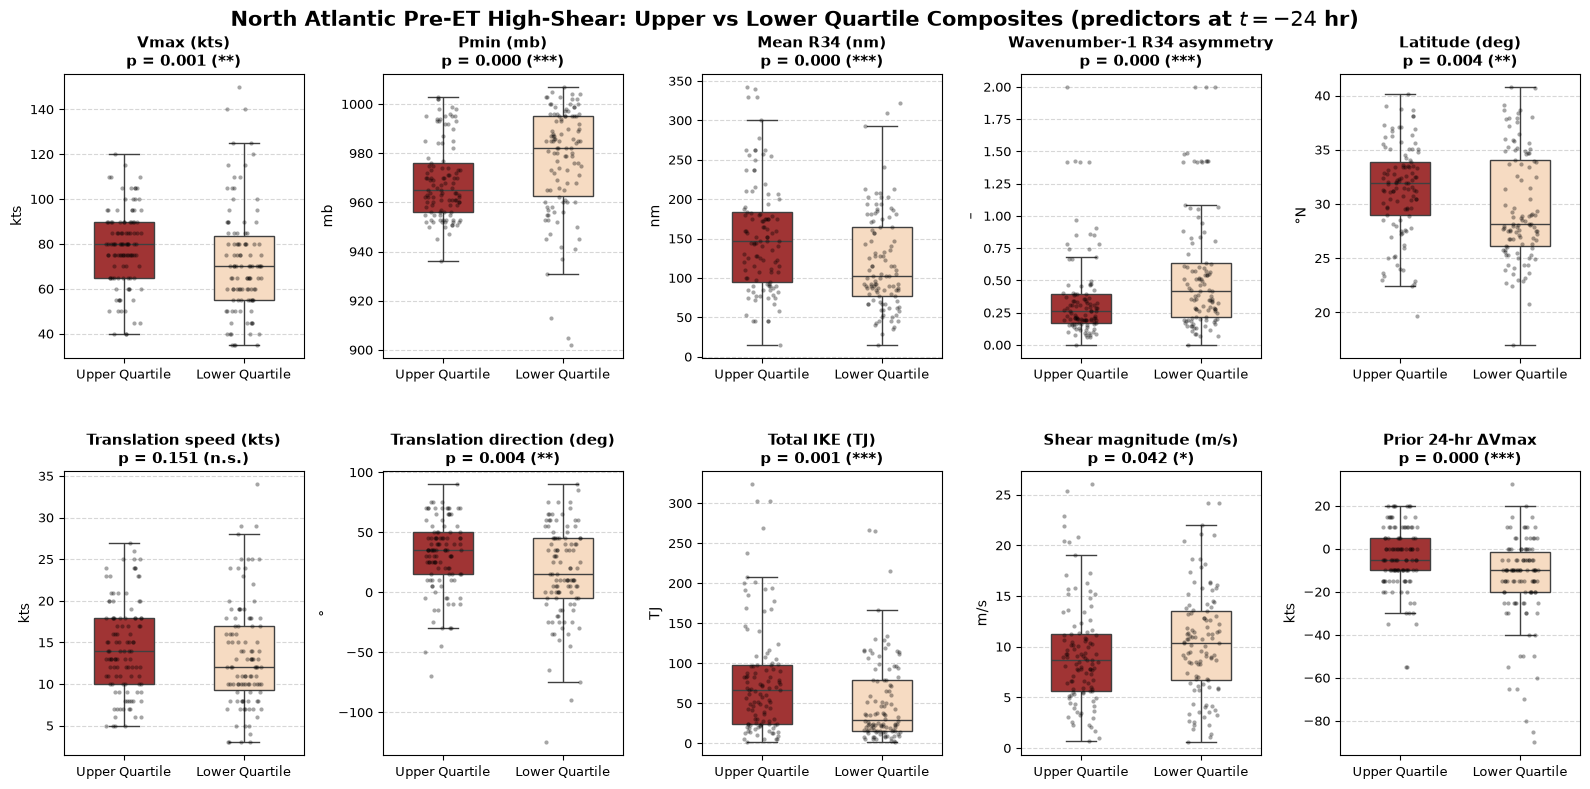

  Plot saved: NorthAtlantic_quartile_composite_boxplots.png

  UPPER vs LOWER DECILE COMPOSITE — West Pacific
  Upper decile threshold (ΔIKE > 0.58 TJ per 6hr)
  Lower decile threshold (ΔIKE < -6.22 TJ per 6hr)
  Upper decile sample size: n=108
  Lower decile sample size: n=108

  --- Storms contributing to UPPER decile ---
    2004  DIANMU           n_obs=1
    2004  MA-ON            n_obs=1
    2004  MEARI            n_obs=2
    2004  NOCK-TEN         n_obs=1
    2005  SAOLA            n_obs=2
    2006  BEBINCA          n_obs=1
    2006  MARIA            n_obs=2
    2006  SOULIK           n_obs=1
    2006  YAGI             n_obs=1
    2007  DANAS            n_obs=2
    2007  MITAG            n_obs=1
    2007  NARI             n_obs=2
    2007  YUTU             n_obs=1
    2008  BAVI             n_obs=2
    2008  KALMAEGI         n_obs=1
    2008  NAKRI            n_obs=1
    2008  RAMMASUN         n_obs=1
    2008  SINLAKU          n_obs=1
    2009  CHOI-WAN         n_obs=1
    2009 

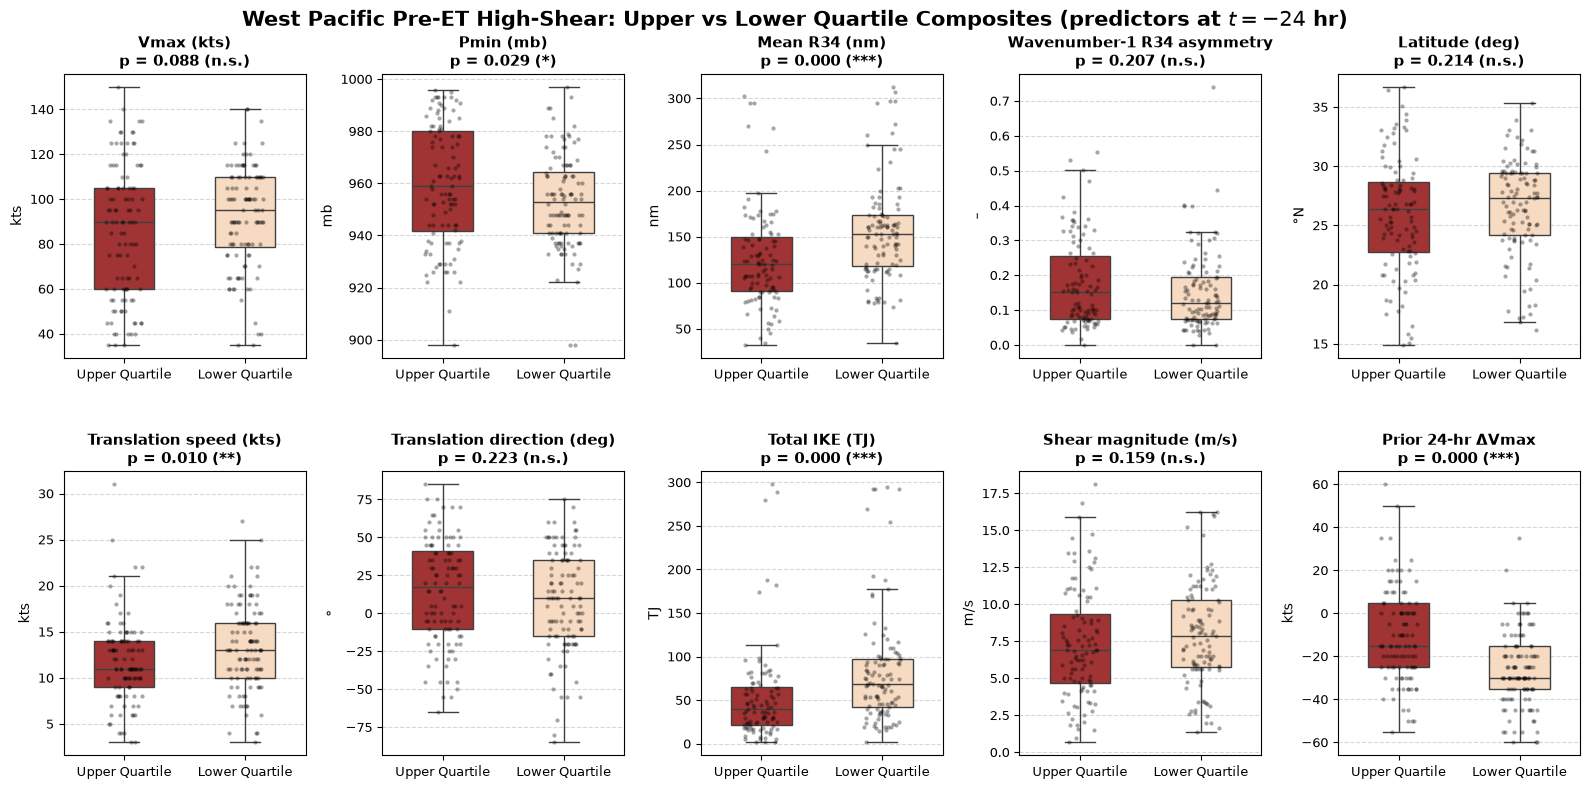

  Plot saved: WestPacific_quartile_composite_boxplots.png


In [5]:
os.makedirs(config.BASE_OUTPUT_DIR, exist_ok=True)
LAG_HOURS = 24


def run_basin_composite(basin):
    print(f"\n{'='*72}")
    print(f"  UPPER vs LOWER DECILE COMPOSITE — {basin}")
    print(f"{'='*72}")

    summary_df, composite, predictors, (upper_thresh, lower_thresh) = compute_decile_composite(
        master_df, basin=basin, upper_pct=0.75, lower_pct=0.25, lag_hours=LAG_HOURS,
    )

    print(f"  Upper decile threshold (\u0394IKE > {upper_thresh:.2f} TJ per 6hr)")
    print(f"  Lower decile threshold (\u0394IKE < {lower_thresh:.2f} TJ per 6hr)")

    upper = composite[composite["group"] == "Upper Quartile"]
    lower = composite[composite["group"] == "Lower Quartile"]
    print(f"  Upper decile sample size: n={len(upper)}")
    print(f"  Lower decile sample size: n={len(lower)}")

    print("\n  --- Storms contributing to UPPER decile ---")
    for _, row in upper.groupby(["storm_year", "storm_name"]).size().reset_index(name="n_obs").iterrows():
        print(f"    {int(row['storm_year'])}  {row['storm_name']:<15}  n_obs={row['n_obs']}")

    print("\n  --- Storms contributing to LOWER decile ---")
    for _, row in lower.groupby(["storm_year", "storm_name"]).size().reset_index(name="n_obs").iterrows():
        print(f"    {int(row['storm_year'])}  {row['storm_name']:<15}  n_obs={row['n_obs']}")

    print(f"\n  --- Summary Table: predictors at t = -{LAG_HOURS} hr ---\n")
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 160)
    print(summary_df.to_string(index=False))

    csv_path = os.path.join(config.BASE_OUTPUT_DIR, f'{basin.replace(" ", "")}_decile_composite_summary.csv')
    summary_df.to_csv(csv_path, index=False)
    print(f"\n  Summary table saved: {csv_path}")

    obs_path = os.path.join(config.BASE_OUTPUT_DIR, f'{basin.replace(" ", "")}_decile_composite_observations.csv')
    keep_cols = ["storm_year", "storm_name", "time_to_et_hrs", "shear_mag_ms", "dIKE_6hr", "group"] + list(predictors.keys())
    composite[keep_cols].to_csv(obs_path, index=True)
    print(f"  Underlying observations saved: {obs_path}")

    plot_decile_boxplots(composite, predictors, basin, config.BASE_OUTPUT_DIR, LAG_HOURS)

    return summary_df, composite, predictors


natl_summary, natl_composite, predictors = run_basin_composite("North Atlantic")
wpac_summary, wpac_composite, _ = run_basin_composite("West Pacific")
